### Using OOP in Regression Analysis

In [29]:
from abc import ABC, abstractmethod
import numpy as np
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.neural_network import MLPRegressor

class MLModel(ABC):
    @abstractmethod
    def train(self, X, y):
        pass

    @abstractmethod
    def predict(self, X):
        pass



### Linear OOP Regression

In [30]:
class LinearRegressionModel(MLModel):
    def __init__(self):
        self.model = LinearRegression()
        
    def train(self, X, y):
        self.model.fit(X, y)
        
    def predict(self, X):
        return self.model.predict(X)


### Polynomial Regression OOP Structure

In [31]:
class PolynomialRegressionModel(MLModel):
    def __init__(self, degree=2):
        self.degree = degree
        self.poly = PolynomialFeatures(degree)
        self.model = LinearRegression()
        
    def train(self, X, y):
        X_poly = self.poly.fit_transform(X)
        self.model.fit(X_poly, y)
        
    def predict(self, X):
        X_poly = self.poly.transform(X)
        return self.model.predict(X_poly)


### Logistic Regression OOP Structure

In [32]:
class LogisticRegressionModel(MLModel):
    def __init__(self):
        self.model = LogisticRegression()
        
    def train(self, X, y):
        self.model.fit(X, y)
        
    def predict(self, X):
        # Returns probability of positive class (can use threshold if needed)
        return self.model.predict_proba(X)[:, 1]


### Neural Network using OOP Structure

In [33]:
class NeuralNetworkRegressionModel(MLModel):
    def __init__(self, hidden_layer_sizes=(100,)):
        self.model = MLPRegressor(hidden_layer_sizes=hidden_layer_sizes, max_iter=1000)
        
    def train(self, X, y):
        self.model.fit(X, y)
        
    def predict(self, X):
        return self.model.predict(X)


### Synthetic Data Generation
 Randomly generating data points to analyse
 X = np.random.rand(100, 1)
 y = 3 * X.squeeze() + 2 + np.random.randn(100) * 0.1
 X: 100 random values between 0 and 1.
 y: A linear relationship with some noise added, so the true relation is roughly y = 3X + 2.
 Fit Models and Predict
Trains each model (linear regression, polynomial regression, neural network regression) on this data.
Makes predictions on the same dataset.
Output
Adding Print Statements 

print(predictions_linear[:5])
print(predictions_poly[:5])
print(predictions_nn[:5])
You'd see the first five predicted values for each model.
What do the predictions look like?
Linear regression: Predicted values close to the true y values, as the data is linear.
Polynomial regression: Also close, could capture more complex relationships if present.
Neural network regression: Predicted values similar, but may differ depending on model complexity and random initialisation.
Example Output (not exact, but illustrative):

[2.10, 2.31, 2.22, 2.44, 2.19]  # Linear model
[2.09, 2.30, 2.22, 2.40, 2.18]  # Polynomial (degree=3)
[2.12, 2.29, 2.22, 2.41, 2.21]  # Neural network
These values represent the model's predictions for the first five points in X.

Summary:
The example is meant to show you how to use the defined classes. Its output, if you add print statements or plot, will be predicted numeric values for the input data, generated by each regression model. You can extend this by evaluating performance or visualising results!







In [34]:
# Example usage (with synthetic data)
if __name__ == "__main__":
    # Create synthetic data
    X = np.random.rand(100, 1)
    y = 3 * X.squeeze() + 2 + np.random.randn(100) * 0.1

    linear_model = LinearRegressionModel()
    linear_model.train(X, y)
    predictions_linear = linear_model.predict(X)

    poly_model = PolynomialRegressionModel(degree=3)
    poly_model.train(X, y)
    predictions_poly = poly_model.predict(X)

    nn_model = NeuralNetworkRegressionModel(hidden_layer_sizes=(50, 20))
    nn_model.train(X, y)
    predictions_nn = nn_model.predict(X)

    print(predictions_linear[:5])
    print(predictions_poly[:5])
    print(predictions_nn[:5])


[2.62347064 3.26555864 3.11623502 3.38051722 2.83085933]
[2.61364484 3.2673461  3.11366417 3.38583703 2.82218619]
[2.62794905 3.26771881 3.11893432 3.38226233 2.83458897]


#### Eg. Linear Regression

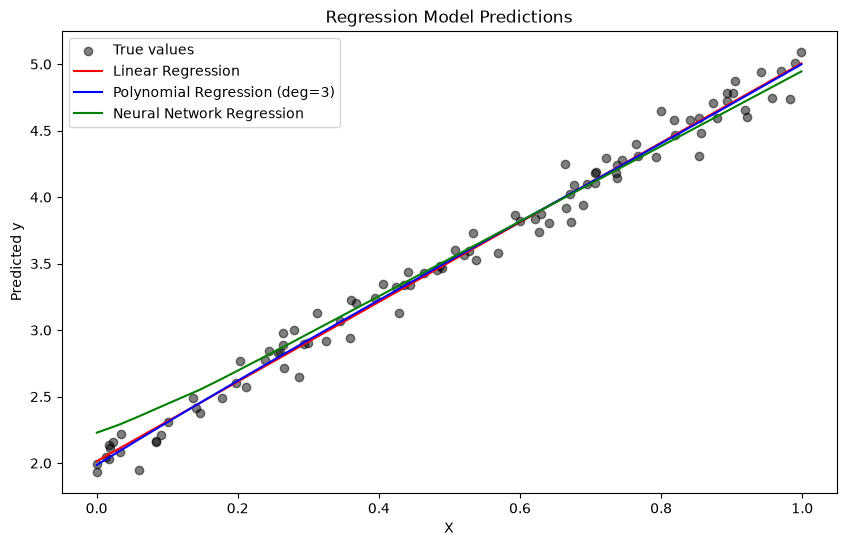

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming the OOP classes from previous answers are already defined

# Create synthetic data
X = np.random.rand(100, 1)
y = 3 * X.squeeze() + 2 + np.random.randn(100) * 0.1

# Train models
linear_model = LinearRegressionModel()
linear_model.train(X, y)
predictions_linear = linear_model.predict(X)

poly_model = PolynomialRegressionModel(degree=3)
poly_model.train(X, y)
predictions_poly = poly_model.predict(X)

nn_model = NeuralNetworkRegressionModel(hidden_layer_sizes=(50, 20))
nn_model.train(X, y)
predictions_nn = nn_model.predict(X)

# Sort X for plotting lines (optional, makes lines smooth)
sort_idx = np.argsort(X.squeeze())
X_sorted = X[sort_idx]
y_sorted = y[sort_idx]
linear_sorted = predictions_linear[sort_idx]
poly_sorted = predictions_poly[sort_idx]
nn_sorted = predictions_nn[sort_idx]

# Plot results
plt.figure(figsize=(10, 6))
plt.scatter(X, y, label="True values", color="black", alpha=0.5)
plt.plot(X_sorted, linear_sorted, label="Linear Regression", color="red")
plt.plot(X_sorted, poly_sorted, label="Polynomial Regression (deg=3)", color="blue")
plt.plot(X_sorted, nn_sorted, label="Neural Network Regression", color="green")
plt.title("Regression Model Predictions")
plt.xlabel("X")
plt.ylabel("Predicted y")
plt.legend()
plt.show()


#### E.g. Polynomial Regression

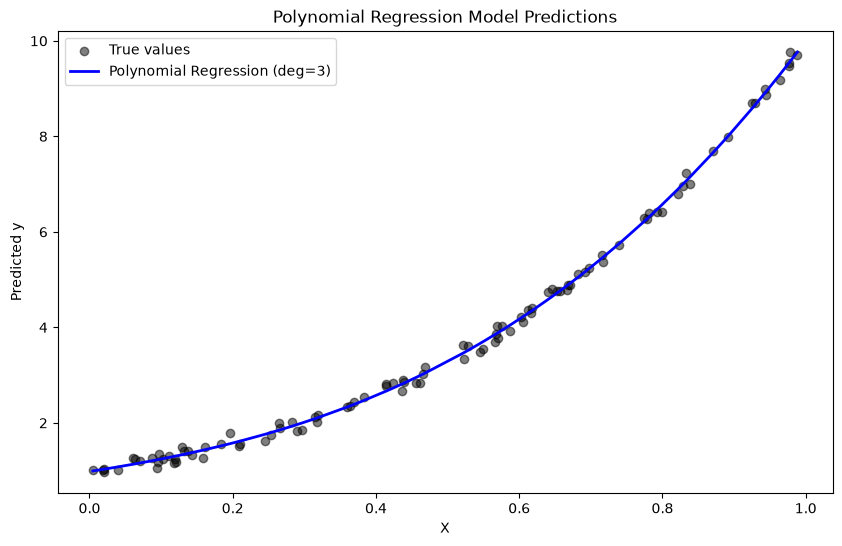

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# --- Polynomial Regression Model Class ---
class PolynomialRegressionModel:
    def __init__(self, degree=3):
        self.degree = degree
        self.poly = PolynomialFeatures(degree)
        self.model = LinearRegression()
        
    def train(self, X, y):
        X_poly = self.poly.fit_transform(X)
        self.model.fit(X_poly, y)
        
    def predict(self, X):
        X_poly = self.poly.transform(X)
        return self.model.predict(X_poly)

# --- Generate Synthetic Nonlinear Data ---
np.random.seed(0)
X = np.random.rand(100, 1)
y = 4 * X.squeeze()**3 + 3 * X.squeeze()**2 + 2 * X.squeeze() + 1 + np.random.randn(100) * 0.1

# --- Polynomial Regression ---
poly_model = PolynomialRegressionModel(degree=3)
poly_model.train(X, y)
predictions_poly = poly_model.predict(X)

# --- Sorting X for Smooth Plot ---
sort_idx = np.argsort(X.squeeze())
X_sorted = X[sort_idx]
y_sorted = y[sort_idx]
poly_sorted = predictions_poly[sort_idx]

# --- Plot Results ---
plt.figure(figsize=(10, 6))
plt.scatter(X, y, label="True values", color="black", alpha=0.5)
plt.plot(X_sorted, poly_sorted, label="Polynomial Regression (deg=3)", color="blue", linewidth=2)
plt.title("Polynomial Regression Model Predictions")
plt.xlabel("X")
plt.ylabel("Predicted y")
plt.legend()
plt.show()


#### Eg. of loading data from a file and fitting a polynomial

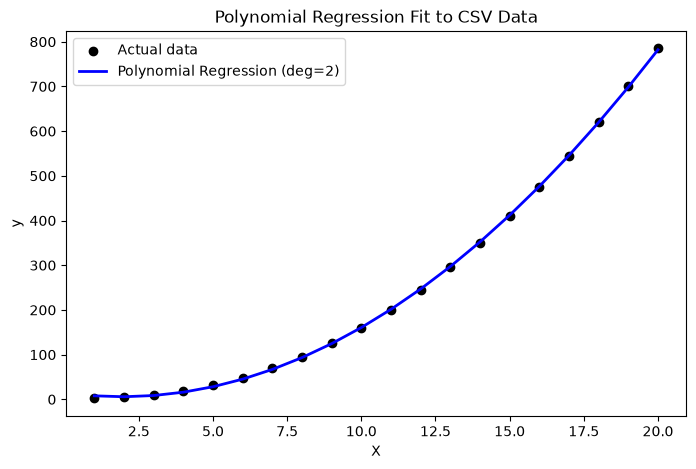

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# --- Load Data ---
df = pd.read_csv('data2.csv')
X = df[['X']].values  # Ensure 2D array for sklearn
y = df['y'].values

# --- Polynomial Regression Model Class ---
class PolynomialRegressionModel:
    def __init__(self, degree=2):
        self.degree = degree
        self.poly = PolynomialFeatures(degree)
        self.model = LinearRegression()
        
    def train(self, X, y):
        X_poly = self.poly.fit_transform(X)
        self.model.fit(X_poly, y)
        
    def predict(self, X):
        X_poly = self.poly.transform(X)
        return self.model.predict(X_poly)

# --- Train and Predict ---
poly_model = PolynomialRegressionModel(degree=2)
poly_model.train(X, y)
predictions_poly = poly_model.predict(X)

# --- Sorting for Plot ---
sort_idx = np.argsort(X.squeeze())
X_sorted = X.squeeze()[sort_idx]
y_sorted = y[sort_idx]
poly_sorted = predictions_poly[sort_idx]

# --- Plot Results ---
plt.figure(figsize=(8, 5))
plt.scatter(X, y, label="Actual data", color="black")
plt.plot(X_sorted, poly_sorted, color="blue", label="Polynomial Regression (deg=2)", linewidth=2)
plt.title("Polynomial Regression Fit to CSV Data")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()


#### Determining the best fit using Mean Squared Error (MSE)

Best polynomial degree: 3
MSE for each degree: [275.0222222222224, 5.610904665201983e-28, 5.249080463340612e-28, 3.3566688901241734e-27, 0.0005351669541634067]


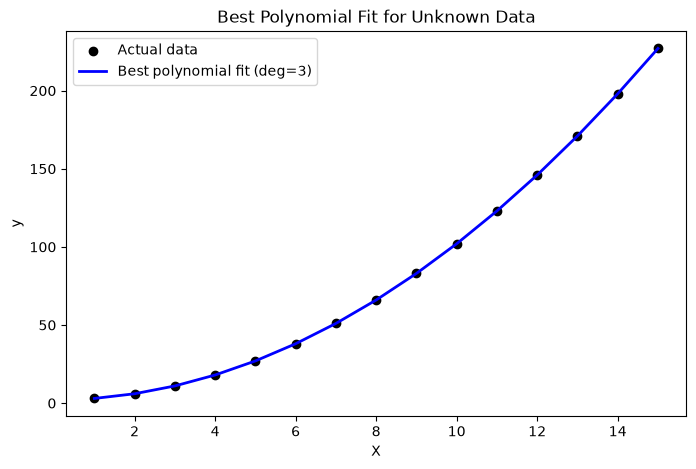

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

# --- Load Data ---
df = pd.read_csv('data3.csv')
X = df[['X']].values
y = df['y'].values

# --- Try Various Polynomial Degrees ---
max_degree = 5
mse_scores = []
models = []
predictions = []

for degree in range(1, max_degree+1):
    poly = PolynomialFeatures(degree)
    X_poly = poly.fit_transform(X)
    model = LinearRegression().fit(X_poly, y)
    y_pred = model.predict(X_poly)
    
    mse = mean_squared_error(y, y_pred)
    mse_scores.append(mse)
    models.append(model)
    predictions.append(y_pred)

# --- Select the Best Degree ---
best_degree = np.argmin(mse_scores) + 1
best_model = models[best_degree-1]
best_poly = PolynomialFeatures(best_degree)
best_X_poly = best_poly.fit_transform(X)
best_pred = best_model.predict(best_X_poly)

print(f"Best polynomial degree: {best_degree}")
print(f"MSE for each degree: {mse_scores}")

# --- Plot Results ---
sort_idx = np.argsort(X.squeeze())
X_sorted = X.squeeze()[sort_idx]
y_sorted = y[sort_idx]
best_pred_sorted = best_pred[sort_idx]

plt.figure(figsize=(8,5))
plt.scatter(X, y, color="black", label="Actual data")
plt.plot(X_sorted, best_pred_sorted, color="blue", label=f"Best polynomial fit (deg={best_degree})", linewidth=2)
plt.title("Best Polynomial Fit for Unknown Data")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()


#### E.g. Using R squared to determine the best fit for the data.

Best polynomial degree (highest R squared): 5
R squared for each degree: [0.8762625581490814, 0.9978290093669357, 0.9991103539600731, 0.999124940590052, 0.9991301937127509]


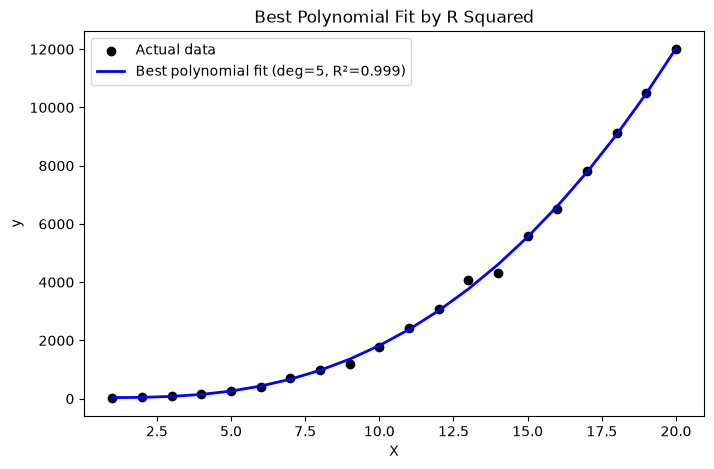

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# --- Load Data ---
df = pd.read_csv('data4.csv')
X = df[['X']].values
y = df['y'].values

# --- Try Various Polynomial Degrees and Compute R Squared ---
max_degree = 5
r2_scores = []
models = []
predictions = []

for degree in range(1, max_degree+1):
    poly = PolynomialFeatures(degree)
    X_poly = poly.fit_transform(X)
    model = LinearRegression().fit(X_poly, y)
    y_pred = model.predict(X_poly)
    
    r2 = model.score(X_poly, y)  # R squared
    r2_scores.append(r2)
    models.append(model)
    predictions.append(y_pred)

# --- Select the Best Degree ---
best_degree = np.argmax(r2_scores) + 1  # Highest R squared
best_model = models[best_degree-1]
best_poly = PolynomialFeatures(best_degree)
best_X_poly = best_poly.fit_transform(X)
best_pred = best_model.predict(best_X_poly)

print(f"Best polynomial degree (highest R squared): {best_degree}")
print(f"R squared for each degree: {r2_scores}")

# --- Plot Results ---
sort_idx = np.argsort(X.squeeze())
X_sorted = X.squeeze()[sort_idx]
y_sorted = y[sort_idx]
best_pred_sorted = best_pred[sort_idx]

plt.figure(figsize=(8,5))
plt.scatter(X, y, color="black", label="Actual data")
plt.plot(X_sorted, best_pred_sorted, color="blue", 
         label=f"Best polynomial fit (deg={best_degree}, R²={r2_scores[best_degree-1]:.3f})", linewidth=2)
plt.title("Best Polynomial Fit by R Squared")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()
